# Catastrophic forgetting — SGD vs L2 vs EWC on Permuted MNIST

Three fixes vs. the buggy version:
1. **Fisher is computed per-sample** (square the per-sample gradient, then average), not from batch-averaged gradients.
2. **Plain SGD** — Adam's per-parameter preconditioning fights EWC's per-parameter importance scaling.
3. **Best λ chosen by grid sweep on the real 3-task experiment** — not by separate CV with mismatched setup.

Expected result: SGD forgets, L2 partially protects, EWC protects best.

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# ── Config ───────────────────────────────────────────────────
SEED     = 42
EPOCHS   = 5
BATCH    = 128
LR       = 0.1          # plain SGD
HIDDEN   = 200
N_TASKS  = 3
N_FISHER = 500          # samples used to estimate the Fisher diagonal
N_TRAIN  = 20000        # subset of MNIST → keeps the sweep fast (set to None for full)

# Grids swept on the actual 3-task experiment
GRID_L2  = [0.01, 0.05, 0.1, 0.5, 1.0]
GRID_EWC = [50, 100, 200, 400, 800, 1600]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED)
print('device:', device)

device: cpu


In [8]:
# ── Data: 3 permuted-MNIST tasks ─────────────────────────────
tf = transforms.Compose([transforms.ToTensor(),
                         transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=tf)

if N_TRAIN is not None:
    idx = torch.randperm(len(train_ds))[:N_TRAIN]
    train_ds = Subset(train_ds, idx.tolist())

def make_loader(ds, perm, shuffle):
    def collate(batch):
        x = torch.stack([img.view(-1)[perm] for img, _ in batch])
        y = torch.tensor([lbl for _, lbl in batch])
        return x, y
    return DataLoader(ds, BATCH, shuffle=shuffle, collate_fn=collate)

# Task 1 = identity, tasks 2-3 = random pixel permutations
perms = [torch.arange(784)] + [torch.randperm(784) for _ in range(N_TASKS - 1)]
tasks = [(make_loader(train_ds, p, True),
          make_loader(test_ds,  p, False)) for p in perms]

In [9]:
# ── Model + helpers ──────────────────────────────────────────
def make_model():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Linear(784, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, 10),
    ).to(device)

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
        total   += len(yb)
    return correct / total

def snapshot(model):
    return {n: p.clone().detach() for n, p in model.named_parameters()}

In [10]:
# ── Fisher diagonal — per-sample, the correct way ────────────
#
#     F_i  ≈  E_(x,y)[ ( d log p(y|x,θ) / dθ_i )^2 ]
#
# We average the SQUARES of PER-SAMPLE gradients.

def compute_fisher(model, loader, n_samples=N_FISHER):
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    model.eval()
    seen = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        for xi, yi in zip(xb, yb):
            if seen >= n_samples:
                break
            model.zero_grad()
            logp = F.log_softmax(model(xi.unsqueeze(0)), dim=1)
            F.nll_loss(logp, yi.unsqueeze(0)).backward()
            for n, p in model.named_parameters():
                fisher[n] += p.grad.detach() ** 2
            seen += 1
        if seen >= n_samples:
            break
    return {n: v / seen for n, v in fisher.items()}

In [11]:
# ── One training epoch (lam is now a parameter, not a global) ─
def train_epoch(model, loader, opt, method, lam,
                anchor=None, fisher=None, snaps=None):
    model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = F.cross_entropy(model(xb), yb)

        if method == 'ewc' and anchor is not None:
            penalty = sum((fisher[n] * (p - anchor[n]).pow(2)).sum()
                          for n, p in model.named_parameters())
            loss = loss + (lam / 2) * penalty

        elif method == 'l2' and snaps:
            penalty = sum((p - snap[n]).pow(2).sum()
                          for snap in snaps
                          for n, p in model.named_parameters())
            loss = loss + (lam / 2) * penalty

        loss.backward()
        opt.step()

In [12]:
# ── Full 3-task experiment as a function ────────────────────
def run_experiment(method, lam, verbose=False):
    """
    Train sequentially on N_TASKS tasks and report:
      curves      : list[phase][task_id] = list of accs over epochs
      mean_final  : mean of final accs on all tasks at end of last phase
      final_accs  : list of final accs on each task at end of last phase
    """
    model = make_model()
    opt   = optim.SGD(model.parameters(), lr=LR)

    anchor       = None    # EWC: latest snapshot
    fisher_accum = None    # EWC: running sum of Fisher diagonals
    snaps        = []      # L2 : all past snapshots
    all_curves   = []

    for task_id in range(N_TASKS):
        train_loader, _ = tasks[task_id]
        curves = [[] for _ in range(N_TASKS)]

        for _ in range(EPOCHS):
            train_epoch(model, train_loader, opt, method, lam,
                        anchor=anchor, fisher=fisher_accum, snaps=snaps)
            for i in range(N_TASKS):
                curves[i].append(accuracy(model, tasks[i][1]))

        all_curves.append(curves)
        if verbose:
            finals = [f'{curves[i][-1]:.2f}' for i in range(N_TASKS)]
            print(f"  After task {task_id+1}  →  test accs: {finals}")

        new_snap = snapshot(model)
        if method == 'l2':
            snaps.append(new_snap)
        elif method == 'ewc':
            anchor = new_snap
            new_f  = compute_fisher(model, train_loader)
            fisher_accum = new_f if fisher_accum is None else \
                           {n: fisher_accum[n] + new_f[n] for n in new_f}

    final_accs = [all_curves[N_TASKS - 1][i][-1] for i in range(N_TASKS)]
    mean_final = float(np.mean(final_accs))
    return all_curves, mean_final, final_accs

In [13]:
# ── Phase 1: grid sweep on the actual 3-task experiment ──────
# Score = mean final test accuracy across all 3 tasks (after phase 3).
# This is the metric we actually care about — no proxy, no mismatched CV setup.

print("=" * 60)
print("Phase 1 — grid sweep over λ")
print("=" * 60)

scores_l2 = {}
print("\n--- L2 sweep ---")
for lam in GRID_L2:
    _, m, finals = run_experiment('l2', lam)
    scores_l2[lam] = m
    print(f"  λ={lam:6.3f}  →  finals {[f'{a:.2f}' for a in finals]}  mean={m:.3f}")

scores_ewc = {}
print("\n--- EWC sweep ---")
for lam in GRID_EWC:
    _, m, finals = run_experiment('ewc', lam)
    scores_ewc[lam] = m
    print(f"  λ={lam:6.0f}  →  finals {[f'{a:.2f}' for a in finals]}  mean={m:.3f}")

best_l2  = max(scores_l2,  key=scores_l2.get)
best_ewc = max(scores_ewc, key=scores_ewc.get)
print(f"\nBest λ  L2 = {best_l2}    (mean acc = {scores_l2[best_l2]:.3f})")
print(f"Best λ EWC = {best_ewc}   (mean acc = {scores_ewc[best_ewc]:.3f})")

Phase 1 — grid sweep over λ

--- L2 sweep ---
  λ= 0.010  →  finals ['0.95', '0.88', '0.93']  mean=0.920
  λ= 0.050  →  finals ['0.95', '0.75', '0.87']  mean=0.858
  λ= 0.100  →  finals ['0.95', '0.75', '0.82']  mean=0.840
  λ= 0.500  →  finals ['0.96', '0.67', '0.64']  mean=0.755
  λ= 1.000  →  finals ['0.95', '0.55', '0.51']  mean=0.672

--- EWC sweep ---
  λ=    50  →  finals ['0.94', '0.86', '0.92']  mean=0.909
  λ=   100  →  finals ['0.10', '0.10', '0.10']  mean=0.098
  λ=   200  →  finals ['0.10', '0.10', '0.10']  mean=0.098
  λ=   400  →  finals ['0.10', '0.10', '0.10']  mean=0.098
  λ=   800  →  finals ['0.10', '0.10', '0.10']  mean=0.098
  λ=  1600  →  finals ['0.10', '0.10', '0.10']  mean=0.098

Best λ  L2 = 0.01    (mean acc = 0.920)
Best λ EWC = 50   (mean acc = 0.909)


In [14]:
# ── Phase 2: final experiment with the best λ for each method ─
print("=" * 60)
print("Phase 2 — final experiment with the best λs")
print("=" * 60)

LAM = {'sgd': 0, 'l2': best_l2, 'ewc': best_ewc}
results = {}

for method in ['sgd', 'l2', 'ewc']:
    print(f"\n=== {method.upper()}  (λ={LAM[method]}) ===")
    curves, mean_final, _ = run_experiment(method, LAM[method], verbose=True)
    results[method] = curves
    print(f"  Final mean accuracy across tasks: {mean_final:.3f}")

Phase 2 — final experiment with the best λs

=== SGD  (λ=0) ===
  After task 1  →  test accs: ['0.96', '0.10', '0.10']
  After task 2  →  test accs: ['0.92', '0.93', '0.08']
  After task 3  →  test accs: ['0.91', '0.91', '0.96']
  Final mean accuracy across tasks: 0.928

=== L2  (λ=0.01) ===
  After task 1  →  test accs: ['0.96', '0.10', '0.10']
  After task 2  →  test accs: ['0.94', '0.93', '0.08']
  After task 3  →  test accs: ['0.95', '0.88', '0.93']
  Final mean accuracy across tasks: 0.920

=== EWC  (λ=50) ===
  After task 1  →  test accs: ['0.96', '0.10', '0.10']
  After task 2  →  test accs: ['0.95', '0.88', '0.07']
  After task 3  →  test accs: ['0.94', '0.86', '0.92']
  Final mean accuracy across tasks: 0.909


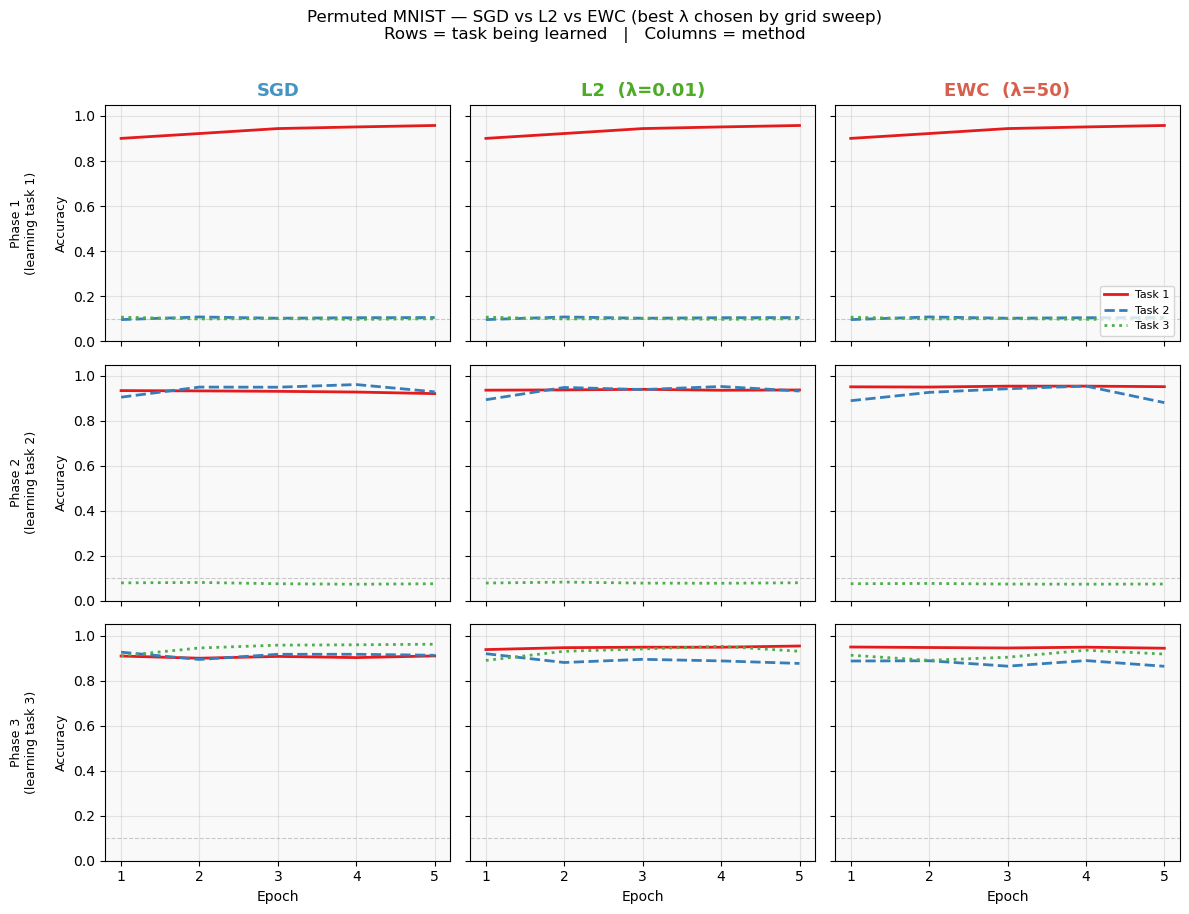

In [15]:
# ── Plot 1: per-method × per-phase curves ────────────────────
method_colors = {'sgd': '#4393c3', 'l2': '#4dac26', 'ewc': '#d6604d'}
task_colors   = ['#e41a1c', '#377eb8', '#4daf4a']
task_lines    = ['-', '--', ':']
epoch_axis    = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(N_TASKS, 3, figsize=(12, 9), sharex=True, sharey=True)
for col, method in enumerate(['sgd', 'l2', 'ewc']):
    for row in range(N_TASKS):
        ax = axes[row][col]
        for i in range(N_TASKS):
            ax.plot(epoch_axis, results[method][row][i],
                    color=task_colors[i], linestyle=task_lines[i],
                    linewidth=2, label=f'Task {i+1}')
        ax.axhline(0.1, color='gray', lw=0.8, ls='--', alpha=0.4)
        ax.set_facecolor('#f9f9f9')
        ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
        if row == 0:
            label = method.upper()
            if method != 'sgd':
                label += f'  (λ={LAM[method]})'
            ax.set_title(label, fontsize=13, fontweight='bold',
                         color=method_colors[method])
        if col == 0:
            ax.set_ylabel(f'Phase {row+1}\n(learning task {row+1})\n\nAccuracy',
                          fontsize=9)
        if row == N_TASKS - 1:
            ax.set_xlabel('Epoch')
        if row == 0 and col == 2:
            ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Permuted MNIST — SGD vs L2 vs EWC (best λ chosen by grid sweep)\n'
             'Rows = task being learned   |   Columns = method', y=1.01)
plt.tight_layout()
plt.savefig('ewc_clean.png', dpi=150, bbox_inches='tight')
plt.show()

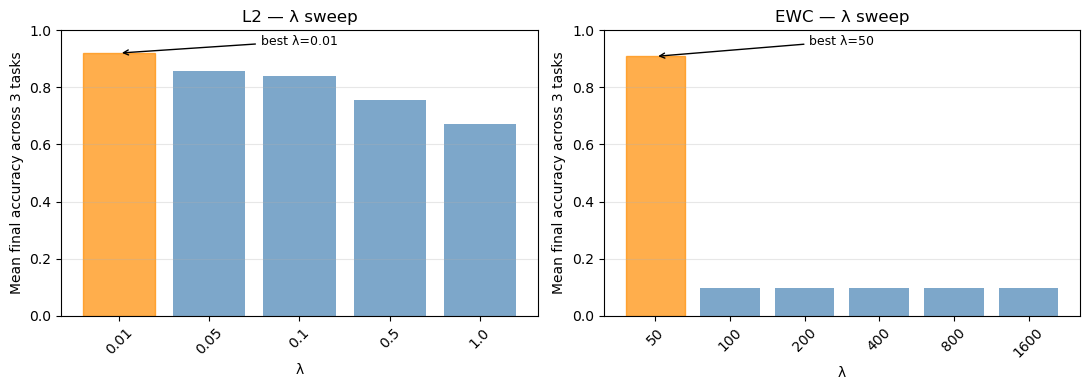

In [16]:
# ── Plot 2: λ sweep curves ───────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, scores, best) in zip(axes2, [
    ('L2',  scores_l2,  best_l2),
    ('EWC', scores_ewc, best_ewc),
]):
    lams = list(scores.keys())
    accs = [scores[l] for l in lams]
    bars = ax.bar([str(l) for l in lams], accs, color='steelblue', alpha=0.7)
    bars[lams.index(best)].set_color('darkorange')
    ax.set_title(f'{name} — λ sweep')
    ax.set_xlabel('λ')
    ax.set_ylabel('Mean final accuracy across 3 tasks')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
    ax.annotate(f'best λ={best}', xy=(lams.index(best), accs[lams.index(best)]),
                xytext=(0.5, 0.95), textcoords='axes fraction',
                ha='center', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='black'))
plt.tight_layout()
plt.savefig('ewc_clean_sweep.png', dpi=150, bbox_inches='tight')
plt.show()